Test for an AAAA vs ABBB System with Varied B2 and K

In [1]:
# THIS CODE USES CUPY; FOR MORE THAN 500 GRIDPOINTS
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit, prange

import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation
import ipywidgets as widgets
from IPython.display import display
import time

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 500 * 10**5 # In timesteps of dt
gridpoints = 1024 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
M = 1 # Units: (nm s)^-1
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84*np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

# Setup for AAAA vs ABBB System
B2aa = 2000 # Units: nm^3
B2bb = 3000 # Units: nm^3
B2ab = 2500 # Units: nm^3

Ka = 1.0E6 # Units: nm^5 
Kb = 8 * 1.0E6 # Units: nm^5 

In [3]:
bytes_needed = 2 * num_saves * gridpoints**2 * 8  # float32, both arrays
print(f"Save arrays require {bytes_needed / 1e9:.2f} GB")
cp.cuda.Device(0).mem_info 
print(num_saves)

Save arrays require 8.41 GB
501


In [4]:
# Initializes array of density values
cp.random.seed(7) # Opens a random number generator instance, seed 7

rho_A = rho_mean * (1.0 + 0.01 * cp.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) # Creates rho values around the mean with slight randomness
rho_A = cp.maximum(rho_A, 1.E-10) # Prevents negative densities
rho_B = rho_mean * (1.0 + 0.01 * cp.random.uniform(low=-1, high=1, size=(gridpoints, gridpoints))) 
rho_B = cp.maximum(rho_B, 1.E-10) 


initial_mass = cp.sum(rho_A) + cp.sum(rho_B)
n = rho_A.shape[0]


def laplacian_2d(function_array):
    """
    Computes the 2D Laplacian of a function, given an array representing that function
    """
    return ( #Uses the inbuilt roll which does allow for periodic boundary conditions
        cp.roll(function_array,  1, axis=1) +
        cp.roll(function_array, -1, axis=1) +
        cp.roll(function_array,  1, axis=0) +
        cp.roll(function_array, -1, axis=0) -
        4.0 * function_array) * inv_dx2




beta_mu_kernel_A = cp.ElementwiseKernel(
    'float64 rho_A, float64 rho_B, float64 lap_rho_A',
    'float64 output',
    f'''
    double rho = rho_A + rho_B;
    double Ca = (rho_A + 0.25 * rho_B) * {valence} * {Da};
    double Xa = (-1.0 + sqrt(1.0 + 4.0 * Ca)) / (2.0 * Ca);
    output = 2.0 * {B2aa} * rho_A + 2.0 * {B2ab} * rho_B
           + log(rho_A)
           + {valence} * log(Xa)
           - {Ka} * lap_rho_A;
    ''',
    'beta_mu_kernel_A'
)

beta_mu_kernel_B = cp.ElementwiseKernel(
    'float64 rho_A, float64 rho_B, float64 lap_rho_B',
    'float64 output',
    f'''
    double rho = rho_A + rho_B;
    double Ca = (rho_A + 0.25 * rho_B) * {valence} * {Da};
    double Cb = (0.75 * rho_B) * {valence} * {Db};
    double Xa = (-1.0 + sqrt(1.0 + 4.0 * Ca)) / (2.0 * Ca);
    double Xb = (-1.0 + sqrt(1.0 + 4.0 * Cb)) / (2.0 * Cb);
    output = 2.0 * {B2ab} * rho_A + 2.0 * {B2bb} * rho_B
           + log(rho_B)
           + ({valence} / 4.0) * (log(Xa) + 3 * log(Xb))
           - {Kb} * lap_rho_B;
    ''',
    'beta_mu_kernel_B'
)






def compute_step_two(rho_A, rho_B):
    lap_A  = laplacian_2d(rho_A)
    lap_B  = laplacian_2d(rho_B)

    mu_A  = beta_mu_kernel_A(rho_A, rho_B, lap_A)
    mu_B  = beta_mu_kernel_B(rho_A, rho_B, lap_B)

    rho_A_step  = dt * M * laplacian_2d(mu_A)
    rho_B_step  = dt * M * laplacian_2d(mu_B)

    return rho_A_step, rho_B_step


# Initializes arrays for saving rho
num_saves = duration // save_interval + 1

rho_A_total_array = cp.zeros((num_saves, gridpoints, gridpoints)) # Third dimension added for 2D grid
rho_B_total_array = cp.zeros((num_saves, gridpoints, gridpoints))

rho_A_total_array[0] = rho_A
rho_B_total_array[0] = rho_B

save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []

start_time = time.perf_counter()
for step in range(duration):

    # Iterates to find new value of rho
    rho_A_step, rho_B_step = compute_step_two(rho_A, rho_B)
    rho_A += rho_A_step
    rho_B += rho_B_step

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_A_total_array[save_index] = rho_A
        rho_B_total_array[save_index] = rho_B
        save_index += 1

        total_mass = cp.sum(rho_A) + cp.sum(rho_B)

        mass_history.append(total_mass)
        time_history.append(step * dt)

        

        rho_A = cp.maximum(rho_A, floor)        
        rho_B = cp.maximum(rho_B, floor)

        time_elapsed = time.perf_counter() - start_time
        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)} at {time_elapsed:1f} seconds")

Progress: 0.0 out of 500.0 at 0.435910 seconds
Progress: 1.0 out of 500.0 at 75.277840 seconds
Progress: 2.0 out of 500.0 at 150.299300 seconds
Progress: 3.0 out of 500.0 at 225.315560 seconds
Progress: 4.0 out of 500.0 at 300.227145 seconds
Progress: 5.0 out of 500.0 at 375.627521 seconds
Progress: 6.0 out of 500.0 at 450.818105 seconds
Progress: 7.0 out of 500.0 at 526.131182 seconds
Progress: 8.0 out of 500.0 at 601.044285 seconds
Progress: 9.0 out of 500.0 at 675.313166 seconds
Progress: 10.0 out of 500.0 at 749.879592 seconds
Progress: 11.0 out of 500.0 at 824.568160 seconds
Progress: 12.0 out of 500.0 at 899.629333 seconds
Progress: 13.0 out of 500.0 at 974.425797 seconds
Progress: 14.0 out of 500.0 at 1049.405175 seconds
Progress: 15.0 out of 500.0 at 1124.076389 seconds
Progress: 16.0 out of 500.0 at 1199.162777 seconds
Progress: 17.0 out of 500.0 at 1274.215174 seconds
Progress: 18.0 out of 500.0 at 1349.357045 seconds
Progress: 19.0 out of 500.0 at 1423.995916 seconds
Progres

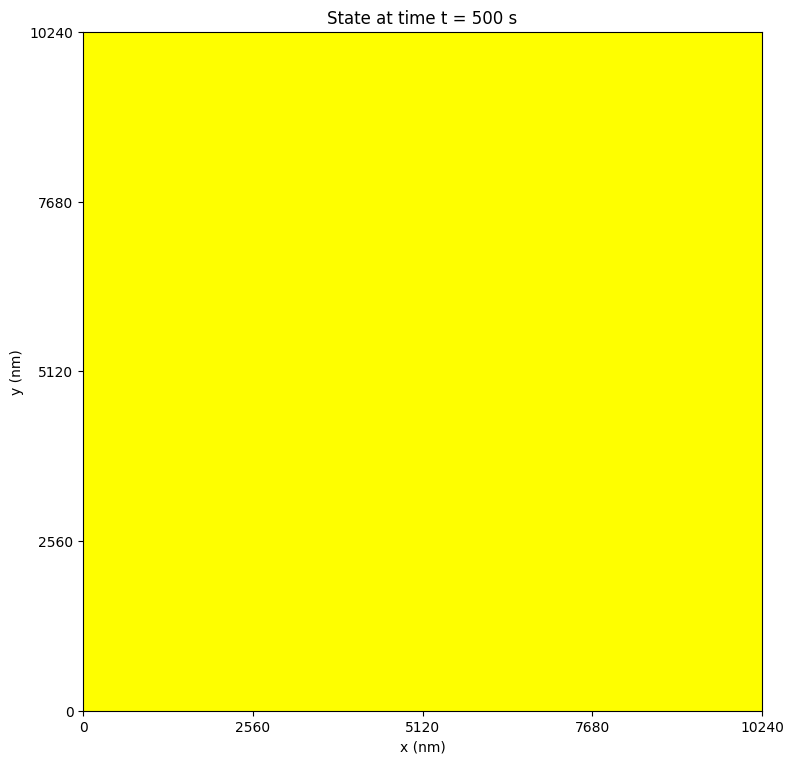

In [9]:
rho_A_np = rho_A.get()
rho_B_np = rho_B.get()

normalized_A = (rho_A_np ) / (np.max(rho_A_np)) #- np.min(rho_A_np))
normalized_B = (rho_B_np ) / (np.max(rho_B_np)) #- np.min(rho_B_np))

normalized_AB = np.zeros_like(normalized_A)

rgb_image = np.dstack((normalized_A, normalized_B, normalized_AB))
t_final = (save_index - 1) * save_interval * dt

plt.figure(figsize=(8, 8))
plt.imshow(rgb_image, extent=[0, grid_length, 0, grid_length], origin='lower')
plt.title(f"State at time t = {t_final:.0f} s")
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.xticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])
plt.yticks([0, grid_length/4, grid_length/2, (3*grid_length)/4, grid_length])

plt.tight_layout()
plt.savefig("rho_final.png", dpi=150)
plt.show()

In [ ]:
# TWO COMPONENT VERSION

fig, ax = plt.subplots(figsize=(8, 8))

n_frames = len(rho_A_total_array)

# Compute global min/max across all frames
A_min  = min(rho_A_total_array[i].get().min()  for i in range(n_frames))
A_max  = max(rho_A_total_array[i].get().max()  for i in range(n_frames))
B_min  = min(rho_B_total_array[i].get().min()  for i in range(n_frames))
B_max  = max(rho_B_total_array[i].get().max()  for i in range(n_frames))

def normalize_global(arr, mn, mx):
    return (arr - mn) / (mx) if mx > mn else np.zeros_like(arr)

# Build first frame
rho_A  = rho_A_total_array[0].get()
rho_B  = rho_B_total_array[0].get()

rgb0 = np.dstack((
    normalize_global(rho_A,  A_min,  A_max),
    normalize_global(rho_B,  B_min,  B_max),
    np.zeros_like(normalize_global(rho_B, B_min, B_max)),
))

im = ax.imshow(rgb0, extent=[0, grid_length, 0, grid_length], origin='lower', animated=True)
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_xticks([0, grid_length/4, grid_length/2, 3*grid_length/4, grid_length])
ax.set_yticks([0, grid_length/4, grid_length/2, 3*grid_length/4, grid_length])
title = ax.set_title("")

def update(frame):
    rho_A  = rho_A_total_array[frame].get()
    rho_B  = rho_B_total_array[frame].get()

    rgb = np.dstack((
        normalize_global(rho_A,  A_min,  A_max),
        normalize_global(rho_B,  B_min,  B_max),
        normalize_global(rho_B,  B_min,  B_max),
    ))
    im.set_array(rgb)
    title.set_text(f"State at time t = {frame:.0f} s")
    return im, title

ani = animation.FuncAnimation(fig, update, frames=range(n_frames), interval=1, blit=True)
ani.save("rho_animation.gif", writer="pillow", dpi=80)
plt.show()